In [19]:
# importing deepBreaks libraries 
from deepBreaks.utils_alt import get_models, get_scores, get_params, make_pipeline
from deepBreaks.preprocessing import MisCare, ConstantCare, URareCare, CustomOneHotEncoder, AminoAcidPropertyEncoder
from deepBreaks.preprocessing import FeatureSelection, CollinearCare
from sklearn.pipeline import FeatureUnion
from deepBreaks.preprocessing import read_data
from deepBreaks.models_alt import model_compare_cv, finalize_top, importance_from_pipe, mean_importance, summarize_results
from deepBreaks.visualization_alt import plot_scatter, dp_plot, plot_imp_model, plot_imp_all
from deepBreaks.preprocessing import write_fasta
import warnings
import datetime
import os
import shutil 
warnings.filterwarnings("ignore")
warnings.simplefilter('ignore')

In [22]:
# defining user params, file pathes, analysis type

#assign your path to folder containing all the datasplits
path = 'C:/Users/safra/Documents/GitHub/visual-physiology-opsin-db/vpod_data/VPOD_1.0/formatted_data_splits/vpod_2023-10-16_12-13-11/'
# path to sequences of interest
seqFileName = f'{path}/VPOD_vert_het_1.0.fasta' 
# path to corresponding metadata of interest
metaDataFileName = f'{path}/vert_meta.tsv' 

# name of the phenotype
mt = 'Lambda_Max'

# type of the sequences
seq_type = 'aa'

# type of the analysis if it is a classification model, then we put cl instead of reg
ana_type = 'reg' 

gap_threshold = 0.50

#Whether or not you want to drop the reference sequence from the training data- Usually 'Bovine' or 'Squid'
drop_ref = True


# making a unique directory for saving the reports of the analysis
print('direcory preparation')
dt_label = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
seqFile = seqFileName.split('/')[2]
#print(seqFile)
seqFile = seqFile.split('.')[0]
#print(seqFile)
report_dir = str(seqFile +'_' + mt + '_' + dt_label)
os.makedirs(report_dir)

# importing metadata
meta_data = read_data(metaDataFileName, seq_type = None, is_main=False)
tr = read_data(seqFileName, seq_type = seq_type, is_main=True, gap_threshold=gap_threshold)


direcory preparation


In [23]:
try:
    reference_seq = tr.loc['Bovine'].copy()
    ref_seq_name = 'bovine'
    if drop_ref == True:
        meta_data = meta_data.drop('Bovine')
    #print(bovine)
except:
    reference_seq = tr.loc['Squid'].copy()
    ref_seq_name = 'squid'
    #print(squid)

In [24]:

reference_seq.to_csv(path_or_buf= f'{report_dir}/ref_sequence.csv',index = True,mode="w")


tr = tr.merge(meta_data.loc[:, mt],  left_index=True, right_index=True)
tr.shape

y = tr.loc[:, mt].values
tr.drop(mt, axis=1, inplace=True)
print('Shape of data is: ', tr.shape)

#rep_pipeline = make_pipeline(
   # steps=[
        #('mc', MisCare(missing_threshold=0.05)),
        #('cc', ConstantCare()),
        #('one_hot', CustomOneHotEncoder()),
        #('aa_prop_encode', AminoAcidPropertyEncoder()),

        #('feature_selection', FeatureSelection(model_type=ana_type, alpha=0.10, keep=False)),
        #('collinear_care', CollinearCare(dist_method='adjusted_rand_score', threshold=0.025, keep=False))
   # ])
prep_pipeline = make_pipeline(
steps=[
    ('mc', MisCare(missing_threshold=0.05)),
    ('cc', ConstantCare()),
    ('aa_prop_encode', AminoAcidPropertyEncoder()),
    ('feature_selection', FeatureSelection(model_type=ana_type, alpha=0.10, keep=False)),
    ('collinear_care', CollinearCare(dist_method='correlation', threshold=0.03, keep=False))
])


Shape of data is:  (720, 352)


In [14]:
tr_hold = tr

In [15]:
tr = tr_hold
tr = prep_pipeline[:4].transform(tr)

tr.head()

KeyboardInterrupt: 

In [25]:
y

array([502. , 502. , 481. , 494. , 494. , 491. , 486. , 490. , 490. ,
       499. , 493. , 498. , 495. , 499. , 492. , 501. , 488. , 487. ,
       498. , 502. , 500. , 497. , 488. , 501. , 504. , 496. , 500. ,
       498. , 505. , 500. , 490. , 498. , 502. , 484. , 488. , 501. ,
       488. , 491. , 503. , 497.9, 503.8, 498. , 499.4, 501.5, 491.5,
       494.5, 483. , 498. , 499. , 497.5, 501. , 495. , 495.5, 498.5,
       493. , 499.5, 498. , 500. , 500. , 493. , 500. , 500. , 491. ,
       497. , 494. , 493. , 492. , 489. , 498. , 500. , 491. , 500. ,
       503. , 502. , 494. , 501. , 501. , 501. , 501. , 482. , 502. ,
       501. , 502. , 496. , 485. , 486. , 486. , 485. , 496. , 483. ,
       526. , 489. , 492. , 507. , 486. , 491. , 479. , 504. , 489. ,
       502. , 491. , 498. , 479. , 488. , 486. , 482. , 482. , 497. ,
       526. , 501. , 507. , 484. , 504. , 490. , 489. , 478. , 511. ,
       503. , 488. , 488. , 501. , 488. , 494. , 491. , 492. , 490. ,
       501. , 504. ,

In [10]:
import joblib
from deepBreaks.utils import load_obj
#import xgboost as xgb
#from xgboost import plot_tree

top_per_mod = 'gbc.pkl'
# Load your LGBM model from the pickle file
with open(top_per_mod, 'rb') as f:
    model_pipeline = joblib.load(f)
#print(model_pipeline)
#print(model_pipeline.steps[1][1])
actual_model = model_pipeline.steps[1][1] 
holder = model_pipeline.steps[0][1][4].aa_encoded_seqs_

In [12]:
holder

,p1_H1,p1_H2,p1_H3,p1_V,p1_P1,p1_P2,p1_SASA,p1_NCI,p1_MASS,p2_H1,...,p292_MASS,p293_H1,p293_H2,p293_H3,p293_V,p293_P1,p293_P2,p293_SASA,p293_NCI,p293_MASS
S1,0.64,-1.3,2.0,94.1,5.7,0.221,2.034,0.002683,131.1986,-0.78,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788
S2,0.00,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.0000,0.00,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788
S3,0.00,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.0000,0.00,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788
S4,0.00,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.0000,0.00,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788
S5,0.00,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.0000,0.00,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S716,0.00,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.0000,0.00,...,97.1167,-0.74,3.0,4.0,62.0,12.3,0.151,1.862,0.006802,129.1155
S717,0.00,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.0000,0.00,...,97.1167,-0.74,3.0,4.0,62.0,12.3,0.151,1.862,0.006802,129.1155
S718,0.64,-1.3,2.0,94.1,5.7,0.221,2.034,0.002683,131.1986,0.04,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788
S719,0.64,-1.3,2.0,94.1,5.7,0.221,2.034,0.002683,131.1986,0.04,...,97.1167,0.62,-0.5,2.0,27.5,8.1,0.046,1.181,0.007187,71.0788


In [14]:
print(type(holder))

<class 'pandas.core.frame.DataFrame'>


In [27]:
holder.shape
max_len = holder.shape[1]

In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
import numpy as np
from keras.regularizers import l1, l2  
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, TimeDistributed, Attention
from tensorflow.keras.models import Sequential

def reshape_data(df, max_sequence_length):
    data_array = df.to_numpy()
    data_array = data_array.reshape(data_array.shape[0], max_sequence_length, -1) 
    return data_array


X_train, X_test, y_train, y_test = train_test_split(holder, y, test_size=0.2)
# Apply the reshaping
X_train_array = reshape_data(X_train, max_len) 
X_test_array = reshape_data(X_test, max_len) 


# Simple CNN example
model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=5, activation='relu', kernel_regularizer=l2(0.005)), 
    tf.keras.layers.MaxPooling1D(pool_size=1),
     # Add more convolutional layers:
    tf.keras.layers.Conv1D(filters=64, kernel_size=10, activation='relu'), 
    tf.keras.layers.MaxPooling1D(pool_size=1),  
    tf.keras.layers.Conv1D(filters=128, kernel_size=25, activation='relu', kernel_regularizer=l2(0.01)), 
    tf.keras.layers.MaxPooling1D(pool_size=2),
    # Add dense layers:
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l1(0.005)),  
    tf.keras.layers.Dense(1)  # Output layer for lambda max prediction
])

model.compile(loss="mse", optimizer="adam")
model.fit(X_train_array, y_train, epochs=50, validation_data=(X_test_array, y_test))

Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 783ms/step - loss: 341039.3125 - val_loss: 4269.0479
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 781ms/step - loss: 21952.4824 - val_loss: 6288.9175
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 763ms/step - loss: 6681.0864 - val_loss: 4474.7334
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 782ms/step - loss: 4047.2097 - val_loss: 3746.2002
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 769ms/step - loss: 3253.8115 - val_loss: 2492.0420
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 771ms/step - loss: 1816.8209 - val_loss: 885.1046
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 784ms/step - loss: 715.0543 - val_loss: 584.4569
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 764ms/step - loss: 561.7752 - val_loss: 545.8572
Epoch 9/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 793ms/step - loss: 560.3073 - val_loss: 578.8788
Epoch 10/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 768ms/step - loss: 491.5592 - val_loss: 519.1252
Epoch 11/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 783ms/step - loss: 515.5800 - va

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 714ms/step


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

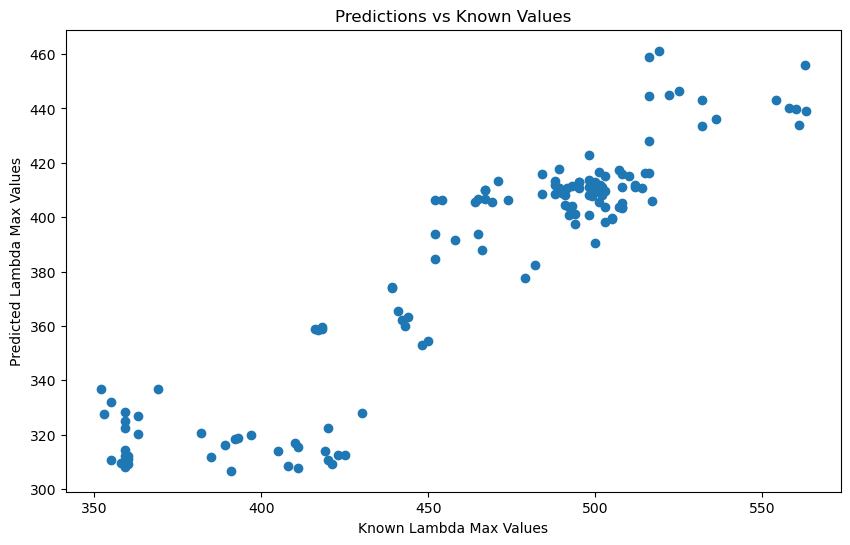

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

predictions = model.predict(X_test_array)

# Assuming you have:
# predictions: The output of your model.predict(...)
# known_values:  An array of the true lambda max values for the corresponding sequences

plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.scatter(y_test, predictions)
plt.xlabel("Known Lambda Max Values")
plt.ylabel("Predicted Lambda Max Values")
plt.title("Predictions vs Known Values")

# Optional: Add a diagonal line for reference
max_value = max(max(y_test), max(predictions)) 
min_value = min(min(y_test), min(predictions)) 
plt.plot([min_value, max_value], [min_value, max_value], 'r--') 

plt.show()


r_squared = r2_score(predictions, y_test)
print("R-squared:", r_squared)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam 
from sklearn.metrics import mean_squared_error


X_train, X_test, y_train, y_test = train_test_split(tr, y, test_size=0.2)
# Apply the reshaping
X_train_array = reshape_data(X_train, max_len) 
X_test_array = reshape_data(X_test, max_len) 

# 1. Model with Adjustments
model = tf.keras.Sequential([
    Bidirectional(LSTM(64, return_sequences = True)),
    Bidirectional(LSTM(64)),
    Dropout(0.2),   # Regularization

    Dense(64, activation='relu', kernel_regularizer='l2'),  # L2 regularization on Dense layer weights
    Dense(1,activation='sigmoid')  
])

# 2. Compilation with Learning Rate
model.compile(loss='mse', metrics=['accuracy'], optimizer='Adam') 

# 3. Training (Unchanged)
model.fit(X_train_array, y_train, epochs=50, batch_size= 64 ,validation_data=(X_test_array, y_test))

# 4. Evaluation
y_pred = model.predict(X_test_array)  # Assuming you have a pre-split X_test
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)


In [ ]:
# importing deepBreaks libraries 
from deepBreaks.utils import get_models, get_scores, get_params, make_pipeline
from deepBreaks.preprocessing import MisCare, ConstantCare, URareCare, CustomOneHotEncoder
from deepBreaks.preprocessing import FeatureSelection, CollinearCare
from deepBreaks.preprocessing import read_data
from deepBreaks.models import model_compare_cv, finalize_top, importance_from_pipe, mean_importance, summarize_results
from deepBreaks.visualization import plot_scatter, dp_plot, plot_imp_model, plot_imp_all
from deepBreaks.preprocessing import write_fasta
import warnings
import datetime
import os
import shutil
import tensorflow_text as text
import tensorflow

In [ ]:
# defining user params, file pathes, analysis type

#assign your path to folder containing all the datasplits
path = './vizphiz_data_splits_2024-04-22_12-15-35'
# path to sequences of interest
seqFileName = f'{path}/rod_aligned_VPOD_het_1.1.fasta' 
# path to corresponding metadata of interest
metaDataFileName = f'{path}/rod_meta.tsv' 

# name of the phenotype
mt = 'Lambda_Max'

# type of the sequences
seq_type = 'aa'

# type of the analysis if it is a classification model, then we put cl instead of reg
ana_type = 'reg' 

gap_threshold = 0.50

#Whether or not you want to drop the reference sequence from the training data- Usually 'Bovine' or 'Squid'
drop_ref = True


# making a unique directory for saving the reports of the analysis
print('direcory preparation')
dt_label = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
seqFile = seqFileName.split('/')[2]
#print(seqFile)
seqFile = seqFile.split('.')[0]
#print(seqFile)
report_dir = str(seqFile +'_' + mt + '_' + dt_label)
os.makedirs(report_dir)

# importing metadata
meta_data = read_data(metaDataFileName, seq_type = None, is_main=False)

tr = read_data(seqFileName, seq_type = seq_type, is_main=True, gap_threshold=gap_threshold)

shutil.copy2(f'{seqFileName}',report_dir)
write_fasta(dat = tr, fasta_file = f'{seqFile}_gap_dropped.fasta' , report_dir = report_dir)

try:
    reference_seq = tr.loc['Bovine'].copy()
    ref_seq_name = 'bovine'
    if drop_ref == True:
        meta_data = meta_data.drop('Bovine')
    #print(bovine)
except:
    reference_seq = tr.loc['Squid'].copy()
    ref_seq_name = 'squid'
    #print(squid)
reference_seq.to_csv(path_or_buf= f'{report_dir}/ref_sequence.csv',index = True,mode="w")


tr = tr.merge(meta_data.loc[:, mt],  left_index=True, right_index=True)
tr.shape

y = tr.loc[:, mt].values
tr.drop(mt, axis=1, inplace=True)
print('Shape of data is: ', tr.shape)

prep_pipeline = make_pipeline(
    steps=[
        ('mc', MisCare(missing_threshold=0.05)),
        ('cc', ConstantCare()),
        ('one_hot', CustomOneHotEncoder()),
        ('feature_selection', FeatureSelection(model_type=ana_type, alpha=0.10, keep=False)),
        ('collinear_care', CollinearCare(dist_method='adjusted_rand_score', threshold=0.025, keep=False))
    ])

#tr = prep_pipeline[:3].fit_transform(tr)
max_len = tr.shape[1]

In [ ]:
tr.fillna('X', inplace=True)    # Replace NaNs (if needed)

tr.head()

In [ ]:

sequences = tr.apply(lambda row: ''.join(row), axis=1).tolist()  # Create a list of joined sequences 
print(sequences)


In [ ]:
from tensorflow_text import Tokenizer

In [ ]:
all_residues = set()
for sequence in sequences:
    all_residues.update(sequence)
print(len(all_residues))
vocab_size = len(all_residues)

In [ ]:
print(sequences)

In [ ]:

# Configure the tokenizer (adjust 'num_words' if needed)
#tokenizer = Tokenizer(vocab) 
#tokenizer.fit_on_texts(sequences)  

# Encode sequences
#encoded_sequences = tokenizer.texts_to_sequences(sequences)


# Tokenization using tensorflow_text
tokenizer = text.UnicodeCharTokenizer()

#tokenizer.fit_on_texts(sequences)  
encoded_sequences = tokenizer.tokenize(sequences).to_tensor() 

#tokenized_sequences = tokenizer.tokenize(tf.constant(sequences))

## Numerical Encoding
#vocab = set(tokenized_sequences.numpy().flatten())  # Collect vocabulary
#encoder = text.WordpieceTokenizer(vocab, suffix_indicator='##') 
#encoded_sequences = encoder.tokenize(tokenized_sequences)

In [ ]:
print(encoded_sequences)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

In [ ]:
vocab_size = 21 # Maximum number of unique amino acid characters
MAX_SEQUENCE_LENGTH = tr.shape[1]
embedding_dim = 32  # Dimensionality of character embeddings

# Input layer
inputs = layers.Input(shape=(MAX_SEQUENCE_LENGTH,))

# Embedding layer (map characters to embeddings)
x = layers.Embedding(vocab_size, embedding_dim)(inputs)

# Bidirectional LSTM layer
x = layers.Bidirectional(layers.LSTM(64))(x)  

# Output layer for regression
outputs = layers.Dense(1)(x) 

model = Model(inputs=inputs, outputs=outputs)


In [ ]:
model.compile(optimizer='adam', loss='mse',metrics=['accuracy']) 


In [ ]:
model.fit(encoded_sequences, y, epochs=10, batch_size=32) 

In [ ]:
# ... (Your data loading and preprocessing code from before)
def reshape_data(df, max_sequence_length):
    data_array = df.to_numpy()
    data_array = data_array.reshape(data_array.shape[0], max_sequence_length, -1) 
    return data_array

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, TimeDistributed, Attention
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.regularizers import l1, l2  
from sklearn.metrics import mean_squared_error


# Constants
MAX_SEQUENCE_LENGTH = tr.shape[1]
VOCAB_SIZE =  21 

X_train, X_test, y_train, y_test = train_test_split(tr, y, test_size=0.2)
# Apply the reshaping
X_train_array = reshape_data(X_train, MAX_SEQUENCE_LENGTH) 
X_test_array = reshape_data(X_test, MAX_SEQUENCE_LENGTH) 


# 1. Stacked Bidirectional LSTM
model=tf.keras.Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=32), 
    Bidirectional(LSTM(64, return_sequences=True)), 
    Bidirectional(LSTM(32, return_sequences=True)),  # Maintain return_sequences for attention

    # Time-Distributed Dense for Calculations at Each Time Step
    TimeDistributed(Dense(32, activation='tanh')),


    # Attention Layer
    # Regularization and Output
    Dropout(0.2), 
    Dense(1) 
])


# 2. Compilation with Learning Rate
model.compile(loss='mse', optimizer='adam',  metrics=['accuracy']) 

# 3. Training (Unchanged)
model.fit(X_train_array, y_train, epochs=50, validation_data=(X_test_array, y_test))

# 4. Evaluation
y_pred = model.predict(X_test_array)  # Assuming you have a pre-split X_test
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
